# **Object simulation**
We will now proceed to simulate the propagation of the wavefront generated by a given object placed along the optical axis.

First, we will analyze how the object propagates on its own, without placing any gratings.

Any object can be defined by its transfer function, which is determined by its geometry and refractive index as follows:
$$T\left(x,y\right) = e^{-\mu\left(x,y\right)+i\phi\left(x,y\right)}$$
If we define the refractive index as:
$$n =1-\delta+i\beta$$
it can be shown that the attenuation term in the transfer function equation is related to $\beta$ as:
$$\mu\left(x,y\right) = \frac{4\pi}{\lambda}\int{\beta\left(x,y\right)dl}$$
where $\lambda$ is the wavelength, and the integral is a line integral along the optical axis through the thickness of the object.

On the other hand, $\phi$ is related to the real part of the refractive index:
$$\phi\left(x,y\right) = -\frac{2\pi}{\lambda}\int{\delta\left(x,y\right)dl}$$

We define the propagator as:
$$H\left(k\right)=e^{iz\sqrt{k^2-k^2_\perp}}$$
The propagated wave function can then be written as:
$$\Phi = H\left(k\right)\cdot F\left[T\left(x,y\right)\right]$$
where $F\left[T\left(x,y\right)\right]$ denotes the Fourier transform of $T\left(x,y\right)$.


# Objects Available
For now, simulations can be performed with a Sphere, Cylinder (hollow or solid) and Wedges.

In [ ]:
import matplotlib.pyplot as plt
import os, sys
sys.path.append(os.path.abspath(os.path.join(os.path.abspath(''), os.pardir)))
import src.PCSim.experiments as exp
import src.PCSim.Geometry as geom
import src.PCSim.Objects as obj
import src.PCSim.source as source
import src.PCSim.detector as detector
import  os

energy = 20 # keV
n = 2048
DSD = 40.1
pixel_size = 10
Beam_distribution = 'Conical'
detector_pixel_size = 1 # micron
detector_FWHM = 1 # microns

# Spectra example: "AAPM_Mo_Mo"

MyGeometry = geom.Geometry(DSD)
MySource = source.Source((0.1,0.1),'Mono', energy, Beam_distribution, pixel_size)
MyObject1 = obj.Cylinder(n, outer_radius=300, inner_radius=50,Orientation='Vertical',pixel_size=pixel_size, material='PMMA', DSO = 15, x_shift_px=0, y_shift_px=0)
#MyObject2 = obj.Cylinder(n, outer_radius=60, inner_radius=30,Orientation='Vertical',pixel_size=pixel_size, material='Au', DSO = 40, x_shift_px=300, y_shift_px=0)
#MyObject = obj.Cylinder(n, 100, pixel_size, 'PMMA', 0, 0, 'Vertical', DSO=40,inner_radius=40)
MyDetectorIdeal = detector.Detector('Ideal', detector_pixel_size, detector_FWHM, 'gaussian', pixel_size)
MyDetectorRealistic = detector.Detector('Realistic', detector_pixel_size, detector_FWHM, 'gaussian', pixel_size)
Sample = [MyObject1]


Intensity = exp.Experiment_Inline(n, MyGeometry, MySource, MyDetectorIdeal,Sample)

#Intensity_detector = utils.convolve(PSF_detector, Intensity)
#Intensity_detector = MyDetector.downsample_image(Intensity)

#Intensity_detector = MyDetectorRealistic.applyDetector(Intensity, gaussian_sigma=0.1)

plt.imshow(Intensity,  'gray')
plt.title('Ideal Intensity')
plt.colorbar()
plt.show()

#plt.imshow(Intensity_detector,  'gray')
#plt.title('Intensity Detector')
#plt.colorbar()
#plt.show()

plt.plot(Intensity[n//4, :])
plt.show()


#im = Image.fromarray(Intensity_detector)
#im.save('Cyl_Analytic_10cm.tif')

Energies: 100%|██████████| 1/1 [00:01<00:00,  1.16s/it]


Energies: 100%|██████████| 1/1 [00:00<00:00,  1.23it/s]


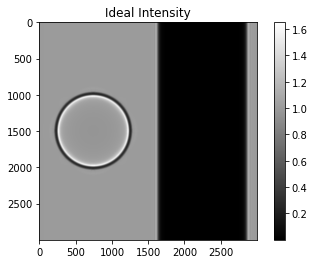

In [4]:
# More than one object

import matplotlib.pyplot as plt
import os, sys
sys.path.append(os.path.abspath(os.path.join(os.path.abspath(''), os.pardir)))
import src.PCSim.experiments as exp
import src.PCSim.Geometry as geom
import src.PCSim.Objects as obj
import src.PCSim.detector as det
import src.PCSim.source as source


n = 1000 
DOD = 1000
DSO = 1000
DSD = 1500
pixel_size = 1
Beam_distribution = 'Conical'
detector_pixel_size = 1
detector_FWHM = 20
energy = 20

MyGeometry = geom.Geometry(DSD)
MySource = source.Source((0.1,0.1),'Mono', energy, Beam_distribution, pixel_size)
MyDetector = det.Detector('Realistic', detector_pixel_size, detector_FWHM, 'gaussian', pixel_size)


#MyObject1 = obj.Sphere(n, 350, pixel_size, 'H2O', 1000, -n//2, 0)
MyObject1 = obj.Sphere(n, 0, 350, pixel_size, 'H2O', 1000, -n//2, 0)
MyObject2 = obj.Cylinder(n, outer_radius=200, inner_radius=0,Orientation='Vertical',pixel_size=pixel_size, material='Au', DSO = 500, x_shift_px=n//2, y_shift_px=0)

Sample = [MyObject1, MyObject2]
Intensity = exp.Experiment_Inline(n, MyGeometry, MySource, MyDetector, Sample, padding=n//4)


plt.imshow(Intensity,  'gray')
plt.title('Ideal Intensity')
plt.colorbar()
plt.show()




## Pure Phase and Pure Absorption Object
We can simulate a Pure Phase and a Pure Absorption Object.


C:\Users\vslga\AppData\Local\Temp/ipykernel_28044/2309813805.py:27: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.
  fig.subplots_adjust(hspace=-0.47, wspace=0.05)
Energies: 100%|██████████| 1/1 [00:00<00:00,  1.53it/s]


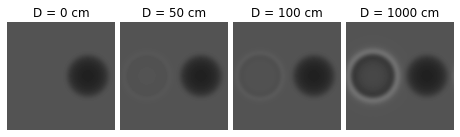

In [4]:


import matplotlib.pyplot as plt
import os, sys
sys.path.append(os.path.abspath(os.path.join(os.path.abspath(''), os.pardir)))
import src.PCSim.experiments as exp
import src.PCSim.Geometry as geom
import src.PCSim.Objects as obj
import src.PCSim.detector as detector
import src.PCSim.source as source

n = 1000

DSD = 2000
pixel_size = 1
Beam_distribution = 'Plane'
detector_pixel_size = 1
detector_FWHM = 1

MyGeometry = geom.Geometry(DSD)
MySource = source.Source((50,50),'Mono', 25, Beam_distribution, pixel_size)
MyDetector = detector.Detector('Ideal', detector_pixel_size, detector_FWHM, 'gaussian', pixel_size)
MyDetectorRealistic = detector.Detector('Realistic', detector_pixel_size, detector_FWHM, 'gaussian', pixel_size)
distances = [0, 50,100, 1000]
i = 0
j = len(distances)
fig, ax = plt.subplots(1, j, figsize = (8,8), constrained_layout=True)
#fig.tight_layout()
fig.subplots_adjust(hspace=-0.47, wspace=0.05)

for prop_distance in distances:
    MyObject1 = obj.Sphere(n, 200, pixel_size, 'Pure_Phase', DSD-prop_distance, -n//2, 0)
    MyObject2 = obj.Sphere(n, 200, pixel_size, 'Pure_Absorption', DSD-prop_distance, +n//2, 0)
    Sample = [MyObject1, MyObject2]
    Intensity = exp.Experiment_Inline(n, MyGeometry, MySource, MyDetector, Sample, padding=n//2)
    #Intensity_detector = MyDetectorRealistic.applyDetector(Intensity, current_pixel_size=detector_pixel_size)

    im1 = ax[i].imshow(Intensity,  'gray', vmin=0.45, vmax = 2.13)
    ax[i].title.set_text(f'D = {prop_distance} cm')
    ax[i].axis('off')
    
    i +=1

plt.show()


# Testing detector new functionalities

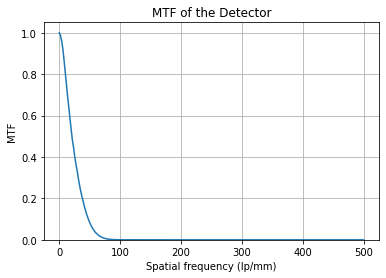

MTF=0.5 at 21.48 lp/mm


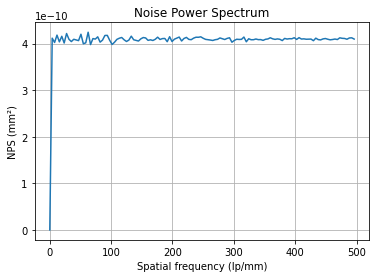

In [2]:
import os, sys
sys.path.append(os.path.abspath(os.path.join(os.path.abspath(''), os.pardir)))
import matplotlib.pyplot as plt
from src.PCSim.detector import Detector

det = Detector(Image_option="Realistic", pixel_size_detector=5.0, FWHM_detector=15.0,
    noise_type="poisson+gaussian", pixel_size=1.0, gaussian_sigma=0.02, N0=1e5, random_seed=42)

# --- MTF ---
freq, mtf = det.compute_MTF(n_pts=512)

plt.figure()
plt.plot(freq, mtf)
plt.xlabel("Spatial frequency (lp/mm)")
plt.ylabel("MTF")
plt.title("MTF of the Detector")
plt.ylim(0, 1.05)
plt.grid(True)
plt.show()

import numpy as np
f50_idx = np.argmin(np.abs(mtf - 0.5))
print(f"MTF=0.5 at {freq[f50_idx]:.2f} lp/mm")

freq_nps, nps = det.compute_NPS(n_images=100, image_shape=(256, 256))

plt.figure()
plt.plot(freq_nps, nps)
plt.xlabel("Spatial frequency (lp/mm)")
plt.ylabel("NPS (mm²)")
plt.title("Noise Power Spectrum")
plt.grid(True)
plt.show()

# CT-like Water Phantom With Inserts

Energies: 100%|██████████| 1/1 [00:00<00:00,  3.58it/s]


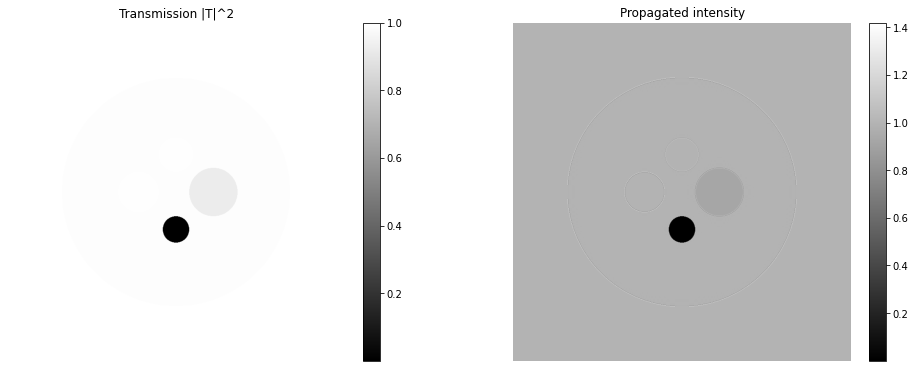

In [10]:
import importlib
from PIL import Image
import matplotlib.pyplot as plt
import os, sys
import numpy as np
sys.path.append(os.path.abspath(os.path.join(os.path.abspath(''), os.pardir)))

import src.PCSim.experiments as exp
import src.PCSim.Geometry as geom
import src.PCSim.Objects as obj
import src.PCSim.source as source
import src.PCSim.detector as detector

exp = importlib.reload(exp)

# === PARÁMETROS ===
energy = 25.0  # keV
pixel_size = 10.0  # µm (mantener en 1 para consistencia con todas las escalas físicas del sistema)
n = 768
DSD = 215.0  # cm
Beam_distribution = 'Plane'
detector_pixel_size = 10.0  # µm
detector_FWHM = 10.0  # µm
phantom_dso = 15.0  # cm

MyGeometry = geom.Geometry(DSD)
MySource = source.Source((1, 1), 'Mono', energy, Beam_distribution, pixel_size)
MyDetectorIdeal = detector.Detector('Ideal', detector_pixel_size, detector_FWHM, 'gaussian', pixel_size)

# Base disk: water phantom
background = obj.Disk(n, radius=2600, thickness=160, pixel_size=pixel_size,
                      material='H2O', DSO=phantom_dso, x_shift=0, y_shift=0)

# Four inserts in the same plane.
insert_al = obj.Disk(n, radius=550, thickness=160, pixel_size=pixel_size,
                    material='Al', DSO=phantom_dso, x_shift=-850, y_shift=0)
insert_al.is_insert = True

insert_pmma = obj.Disk(n, radius=450, thickness=160, pixel_size=pixel_size,
                       material='PMMA', DSO=phantom_dso, x_shift=850, y_shift=0)
insert_pmma.is_insert = True

insert_adipose = obj.Disk(n, radius=380, thickness=160, pixel_size=pixel_size,
                          material='Breast_Adipose', DSO=phantom_dso, x_shift=0, y_shift=850)
insert_adipose.is_insert = True

insert_gold = obj.Disk(n, radius=300, thickness=160, pixel_size=pixel_size,
                       material='Au', DSO=phantom_dso, x_shift=0, y_shift=-850)
insert_gold.is_insert = True

sample_insert = [background, insert_al, insert_pmma, insert_adipose, insert_gold]

T = exp._group_transmission_with_insert_replace(sample_insert, energy, pixel_size)
T2 = np.abs(T) ** 2

intensity_insert = exp.Experiment_Inline(n, MyGeometry, MySource, MyDetectorIdeal, sample_insert, apply_detector=False)

center_row = n // 2

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

im0 = axes[0].imshow(T2, cmap='gray')
axes[0].set_title('Transmission |T|^2')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
axes[0].axis('off')

im1 = axes[1].imshow(intensity_insert, cmap='gray')
axes[1].set_title('Propagated intensity')
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
axes[1].axis('off')

plt.show()

#im = Image.fromarray(Intensity_detector)
#im.save('Cyl_Analytic_10cm.tif')

im = Image.fromarray(intensity_insert)
im.save('Intensity_with_Inserts.tiff')
    
im2 = Image.fromarray(T2)
im2.save('Transmission_with_Inserts.tiff')